
# Sumativa 3 - Modelamiento Predictivo Integrado

## Framingham Heart Study

**Integrantes:**

- Francisco Santelices
- Renato Villazon
- Fabian Castillo

---

### Objetivo

Desarrollar y comparar modelos de regresión logística para predecir el riesgo de enfermedad coronaria a diez años (TenYearCHD), integrando los resultados obtenidos en las Sumativas 1 y 2.

Para ello se realizará:

- Manejo de datos faltantes mediante distintas estrategias de imputación.
- Construcción de múltiples modelos de regresión logística.
- Selección del mejor modelo utilizando criterios estadísticos.
- Validación mediante Bootstrap.
- Comparación del impacto de las distintas estrategias de imputación.#%% md


In [1]:
import numpy as np

np.random.seed(42)

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")

In [2]:
BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebook":
    BASE_DIR = BASE_DIR.parent

CSV_FILE = BASE_DIR / "data" / "framingham.csv"

df = pd.read_csv(CSV_FILE)

print(df.shape)

df.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# 1. Integración de los resultados de las evaluaciones anteriores

La presente evaluación constituye la etapa final del proyecto de análisis predictivo utilizando el conjunto de datos del Framingham Heart Study.

Las decisiones metodológicas adoptadas en esta actividad se fundamentan en los principales resultados obtenidos previamente:

### Sumativa 1

- Identificación de variables asociadas al riesgo cardiovascular mediante análisis descriptivo e inferencial.
- Detección de correlaciones entre variables clínicas.
- Identificación de valores faltantes y aplicación inicial de eliminación por casos completos.

### Sumativa 2

- Validación de parámetros mediante Bootstrap.
- Evaluación de estabilidad utilizando simulaciones Monte Carlo.
- Análisis de robustez frente a outliers.
- Cálculo de tamaños del efecto.
- Diagnóstico de colinealidad entre presión sistólica y diastólica.

A partir de estos resultados se desarrollará un proceso de modelamiento predictivo más robusto, incorporando estrategias alternativas de tratamiento de datos faltantes y comparación de múltiples modelos de regresión logística.

# 2. Tratamiento de datos faltantes

Durante la Sumativa 1 se utilizó la estrategia de eliminación por casos completos (Listwise Deletion), obteniéndose una reducción de aproximadamente el 13,7% de las observaciones originales.

En esta evaluación se compararán tres estrategias de tratamiento de datos faltantes:

- Eliminación por casos completos.
- Imputación simple mediante la media.
- Imputación mediante modelos de regresión.

El objetivo es evaluar el impacto de cada estrategia sobre el desempeño del modelo predictivo.

In [3]:
faltantes = (
    df.isna()
      .sum()
      .reset_index()
)

faltantes.columns = [
    "Variable",
    "Valores faltantes"
]

faltantes["Porcentaje (%)"] = (
    faltantes["Valores faltantes"]
    / len(df)
    *100
)

faltantes = faltantes.sort_values(
    by="Valores faltantes",
    ascending=False
)

faltantes

,Variable,Valores faltantes,Porcentaje (%)
14,glucose,388,9.150943
2,education,105,2.476415
5,BPMeds,53,1.250000
9,totChol,50,1.179245
4,cigsPerDay,29,0.683962
12,BMI,19,0.448113
13,heartRate,1,0.023585
0,male,0,0.000000
7,prevalentHyp,0,0.000000
6,prevalentStroke,0,0.000000


### Interpretación

El análisis de valores faltantes muestra que la mayoría de las variables presenta un porcentaje reducido de datos ausentes. La variable **glucose** concentra la mayor proporción de valores faltantes (9,15%), seguida por **education** (2,48%) y **BPMeds** (1,25%).

Durante la Sumativa 1 se optó por eliminar los registros incompletos mediante *Listwise Deletion*. Sin embargo, esta estrategia implicó la pérdida de aproximadamente un 13,7% de las observaciones originales.

Considerando este resultado, en la presente evaluación se compararán distintas estrategias de tratamiento de datos faltantes con el objetivo de determinar si es posible conservar una mayor cantidad de información sin afectar el desempeño del modelo predictivo.

### Patrón de los datos faltantes

En la Sumativa 2 se observó que la proporción de mujeres era mayor entre los registros excluidos que entre los conservados, mientras que la distribución de `TenYearCHD` no mostró diferencias significativas entre ambos grupos.

Este resultado descarta asumir automáticamente un mecanismo completamente aleatorio (MCAR) y sugiere un patrón compatible con **Missing At Random (MAR)**, dado que la ausencia parece relacionarse con variables observadas, particularmente el sexo.

Esta clasificación se considera una aproximación metodológica y no una demostración definitiva del mecanismo de ausencia. En consecuencia, se comparan estrategias de eliminación e imputación para evaluar la sensibilidad de los resultados.

## 2.1 Eliminación por casos completos (Listwise Deletion)

Como punto de referencia se aplicó la estrategia utilizada durante la Sumativa 1, eliminando todas las observaciones que presentan al menos un valor faltante.

Esta estrategia genera un conjunto de datos completamente limpio, aunque reduce el tamaño de la muestra disponible para el entrenamiento del modelo.

In [4]:
df_listwise = df.dropna().copy()

print("Registros originales :", len(df))
print("Registros finales    :", len(df_listwise))
print()

print(
    "Registros eliminados :",
    len(df) - len(df_listwise)
)

print(
    "Porcentaje eliminado :",
    f"{100*(len(df)-len(df_listwise))/len(df):.2f}%"
)

Registros originales : 4240
Registros finales    : 3658

Registros eliminados : 582
Porcentaje eliminado : 13.73%


## 2.2 Imputación simple

Como segunda estrategia se aplicó una imputación simple diferenciada según la naturaleza de cada variable.

Las variables cuantitativas fueron imputadas mediante su mediana, una medida menos sensible a valores extremos que la media. Para las variables categóricas codificadas numéricamente (`education` y `BPMeds`) se utilizó la categoría más frecuente.

Esta estrategia permite conservar las 4.240 observaciones sin generar valores incompatibles con la escala de las variables.

In [5]:
df_simple = df.copy()

# Variables cuantitativas continuas o discretas
variables_numericas_faltantes = [
    "cigsPerDay",
    "totChol",
    "BMI",
    "heartRate",
    "glucose"
]

# Variables categóricas codificadas numéricamente
variables_categoricas_faltantes = [
    "education",
    "BPMeds"
]

# Imputación simple por mediana para variables numéricas
imputer_mediana = SimpleImputer(strategy="median")

df_simple[variables_numericas_faltantes] = (
    imputer_mediana.fit_transform(
        df_simple[variables_numericas_faltantes]
    )
)

# Imputación por moda para variables categóricas
imputer_moda = SimpleImputer(strategy="most_frequent")

df_simple[variables_categoricas_faltantes] = (
    imputer_moda.fit_transform(
        df_simple[variables_categoricas_faltantes]
    )
)

print(
    "Valores faltantes restantes:",
    int(df_simple.isna().sum().sum())
)

print(
    "Registros conservados:",
    len(df_simple)
)

Valores faltantes restantes: 0
Registros conservados: 4240


## 2.3 Imputación mediante regresión

Como tercera estrategia se aplicaron modelos de regresión para imputar las variables que presentaban valores faltantes.

Para cada variable se seleccionaron entre tres y cinco predictores, considerando las relaciones identificadas durante la Sumativa 1 y las correlaciones cuya estabilidad fue evaluada en la Sumativa 2. Los modelos se ajustaron exclusivamente con observaciones donde la variable a imputar se encontraba disponible.

La imputación se realizó de forma secuencial, comenzando por las variables con menor cantidad de datos ausentes. De esta manera, las variables previamente completadas pudieron utilizarse como predictoras en las etapas posteriores.

Para las variables binarias, ordinales o discretas se aplicaron restricciones posteriores a la predicción, con el fin de conservar valores compatibles con su naturaleza estadística.

In [6]:
# Copia del dataset original para imputación mediante regresión
df_regresion = df.copy()

# Variables predictoras definidas para cada variable con valores faltantes.
# No se utiliza TenYearCHD para evitar filtrar información de la variable objetivo.
predictores_imputacion = {
    "heartRate": [
        "age",
        "sysBP",
        "diaBP",
        "BMI",
        "currentSmoker"
    ],

    "BMI": [
        "age",
        "sysBP",
        "diaBP",
        "totChol",
        "glucose"
    ],

    "cigsPerDay": [
        "age",
        "male",
        "currentSmoker",
        "BMI",
        "heartRate"
    ],

    "totChol": [
        "age",
        "BMI",
        "sysBP",
        "glucose",
        "diabetes"
    ],

    "BPMeds": [
        "age",
        "sysBP",
        "diaBP",
        "prevalentHyp",
        "diabetes"
    ],

    "education": [
        "age",
        "male",
        "currentSmoker",
        "cigsPerDay",
        "BMI"
    ],

    "glucose": [
        "age",
        "BMI",
        "totChol",
        "sysBP",
        "diabetes"
    ]
}

In [7]:
def imputar_por_regresion(
    dataframe,
    variable_objetivo,
    variables_predictoras
):
    """
    Imputa los valores faltantes de una variable mediante
    regresión lineal múltiple.

    El modelo se ajusta con observaciones donde la variable objetivo
    y todos sus predictores están observados.
    """

    df_aux = dataframe.copy()

    mascara_objetivo_observado = df_aux[variable_objetivo].notna()
    mascara_predictores_completos = (
        df_aux[variables_predictoras]
        .notna()
        .all(axis=1)
    )

    mascara_entrenamiento = (
        mascara_objetivo_observado
        & mascara_predictores_completos
    )

    X_completo = df_aux.loc[
        mascara_entrenamiento,
        variables_predictoras
    ]

    y_completo = df_aux.loc[
        mascara_entrenamiento,
        variable_objetivo
    ]

    # Separación interna para evaluar el modelo de imputación
    X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
        X_completo,
        y_completo,
        test_size=0.20,
        random_state=42
    )

    modelo_evaluacion = LinearRegression()

    modelo_evaluacion.fit(
        X_train_imp,
        y_train_imp
    )

    pred_test = modelo_evaluacion.predict(
        X_test_imp
    )

    r2 = r2_score(
        y_test_imp,
        pred_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_imp,
            pred_test
        )
    )

    # Ajuste final con todas las observaciones completas disponibles
    modelo_final = LinearRegression()

    modelo_final.fit(
        X_completo,
        y_completo
    )

    mascara_faltantes = df_aux[
        variable_objetivo
    ].isna()

    X_faltantes = df_aux.loc[
        mascara_faltantes,
        variables_predictoras
    ].copy()

    # Algunos registros a imputar pueden tener predictores faltantes.
    # Se utiliza la mediana del conjunto de entrenamiento como apoyo.
    medianas_entrenamiento = X_completo.median()

    X_faltantes = X_faltantes.fillna(
        medianas_entrenamiento
    )

    valores_predichos = modelo_final.predict(
        X_faltantes
    )

    return {
        "valores_predichos": valores_predichos,
        "mascara_faltantes": mascara_faltantes,
        "n_entrenamiento": len(X_completo),
        "n_imputados": int(mascara_faltantes.sum()),
        "r2": r2,
        "rmse": rmse
    }

In [8]:
orden_imputacion = [
    "heartRate",
    "BMI",
    "cigsPerDay",
    "totChol",
    "BPMeds",
    "education",
    "glucose"
]

resultados_imputacion = []

for variable in orden_imputacion:

    resultado = imputar_por_regresion(
        dataframe=df_regresion,
        variable_objetivo=variable,
        variables_predictoras=predictores_imputacion[variable]
    )

    valores_predichos = resultado[
        "valores_predichos"
    ]

    # Ajustes según la naturaleza de cada variable
    if variable == "BPMeds":
        valores_predichos = (
            valores_predichos >= 0.5
        ).astype(int)

    elif variable == "education":
        valores_predichos = np.clip(
            np.rint(valores_predichos),
            1,
            4
        )

    elif variable == "cigsPerDay":
        valores_predichos = np.clip(
            np.rint(valores_predichos),
            0,
            None
        )

    elif variable in [
        "heartRate",
        "BMI",
        "totChol",
        "glucose"
    ]:
        valores_predichos = np.clip(
            valores_predichos,
            0,
            None
        )

    df_regresion.loc[
        resultado["mascara_faltantes"],
        variable
    ] = valores_predichos

    resultados_imputacion.append({
        "Variable": variable,
        "Registros para entrenar": resultado["n_entrenamiento"],
        "Valores imputados": resultado["n_imputados"],
        "R² validación": resultado["r2"],
        "RMSE validación": resultado["rmse"]
    })

In [9]:
tabla_regresiones_imputacion = pd.DataFrame(
    resultados_imputacion
)

tabla_regresiones_imputacion.round(4)

,Variable,Registros para entrenar,Valores imputados,R² validación,RMSE validación
0,heartRate,4220,1,0.0639,11.7074
1,BMI,3828,19,0.1389,3.7755
2,cigsPerDay,4211,29,0.6194,7.4865
3,totChol,3842,50,0.0704,42.3363
4,BPMeds,4187,53,0.0789,0.1725
5,education,4135,105,0.0316,1.0131
6,glucose,3852,388,0.1879,18.8472


In [10]:
print(
    "Valores faltantes restantes:",
    int(df_regresion.isna().sum().sum())
)

print(
    "Registros conservados:",
    len(df_regresion)
)

Valores faltantes restantes: 0
Registros conservados: 4240


## 2.4 Comparación de estrategias de tratamiento

Finalmente se compararon las tres estrategias implementadas considerando la cantidad de observaciones disponibles para el modelamiento y la presencia de valores faltantes.

Esta comparación permitirá seleccionar el conjunto de datos más adecuado para la construcción y evaluación de los modelos predictivos.

In [11]:
comparacion_imputacion = pd.DataFrame({

    "Estrategia": [
        "Listwise Deletion",
        "Imputación por media",
        "Imputación por regresión"
    ],

    "Registros": [
        len(df_listwise),
        len(df_simple),
        len(df_regresion)
    ],

    "Valores faltantes": [
        int(df_listwise.isna().sum().sum()),
        int(df_simple.isna().sum().sum()),
        int(df_regresion.isna().sum().sum())
    ]
})

comparacion_imputacion

,Estrategia,Registros,Valores faltantes
0,Listwise Deletion,3658,0
1,Imputación por media,4240,0
2,Imputación por regresión,4240,0


## 2.5 Comparación del efecto de las estrategias de imputación

Antes de construir los modelos predictivos, se evaluó si las distintas estrategias de tratamiento de datos faltantes modificaron de forma importante la distribución de las principales variables continuas.

Este análisis permite verificar que la imputación preserve razonablemente las características originales de los datos antes del entrenamiento de los modelos de regresión logística.

In [12]:
variables_comparacion = [
    "age",
    "totChol",
    "BMI",
    "glucose"
]

comparacion_distribuciones = []

for variable in variables_comparacion:

    comparacion_distribuciones.append({

        "Variable": variable,

        "Original":
            df[variable].mean(),

        "Listwise":
            df_listwise[variable].mean(),

        "Imputación simple":
            df_simple[variable].mean(),

        "Imputación regresión":
            df_regresion[variable].mean()

    })

comparacion_distribuciones = pd.DataFrame(
    comparacion_distribuciones
)

comparacion_distribuciones.round(2)

,Variable,Original,Listwise,Imputación simple,Imputación regresión
0,age,49.58,49.55,49.58,49.58
1,totChol,236.70,236.85,236.67,236.74
2,BMI,25.80,25.78,25.80,25.80
3,glucose,81.96,81.85,81.60,81.81


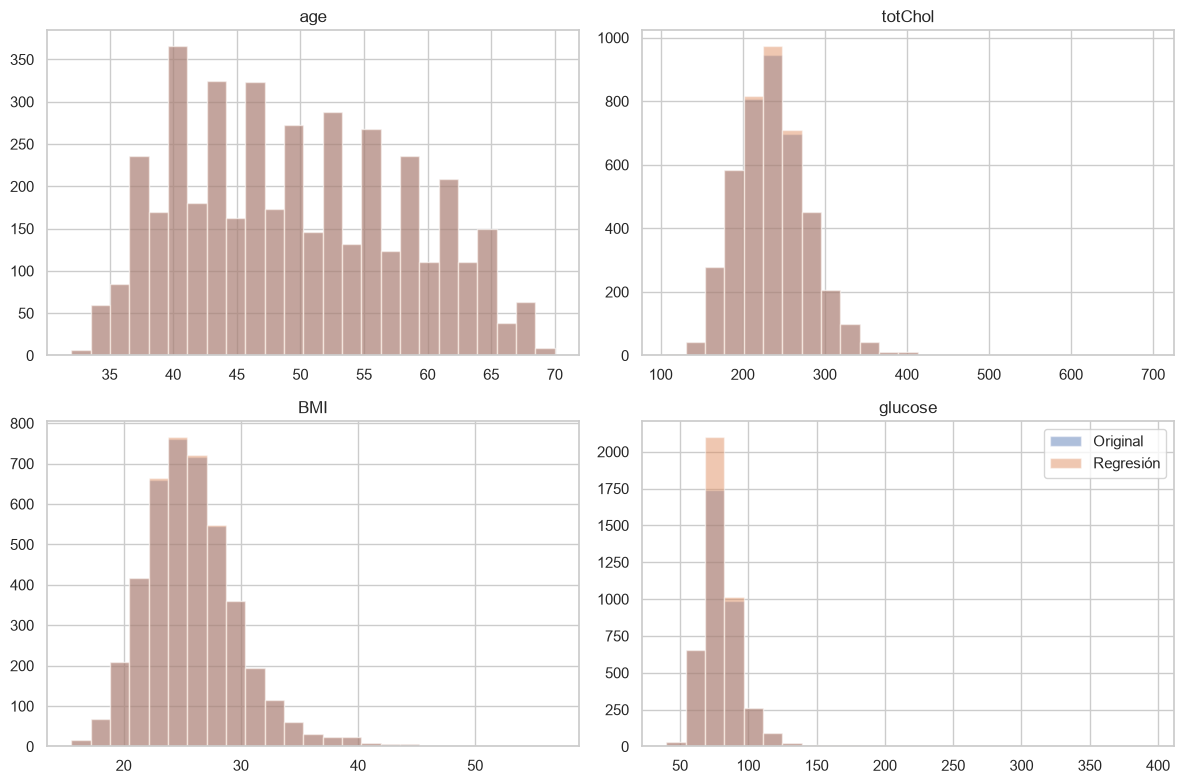

In [13]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

variables = [
    "age",
    "totChol",
    "BMI",
    "glucose"
]

for ax, variable in zip(axes.flatten(), variables):

    ax.hist(
        df[variable].dropna(),
        bins=25,
        alpha=0.45,
        label="Original"
    )

    ax.hist(
        df_regresion[variable],
        bins=25,
        alpha=0.45,
        label="Regresión"
    )

    ax.set_title(variable)

plt.legend()

plt.tight_layout()

plt.show()

### Interpretación

La comparación de las distribuciones indica que las tres estrategias de tratamiento de datos faltantes mantienen valores promedio muy similares a los observados en el conjunto de datos original.

Asimismo, los histogramas muestran que la imputación mediante regresión conserva adecuadamente la forma de la distribución de las principales variables continuas, sin introducir cambios importantes en su tendencia central o dispersión.

Si bien la eliminación por casos completos también preserva las características de la muestra, implica la pérdida de 582 observaciones (13,73%). En cambio, tanto la imputación simple como la imputación mediante regresión permiten conservar la totalidad de los registros disponibles.

Considerando estos resultados, la imputación mediante regresión se utilizará como estrategia principal para la construcción de los modelos predictivos, ya que conserva el tamaño de la muestra y mantiene las relaciones observadas entre las variables.

In [14]:
# Ingeniería de variable: presión de pulso

for dataset in [
    df_listwise,
    df_simple,
    df_regresion
]:
    dataset["pulsePressure"] = (
            dataset["sysBP"]
            - dataset["diaBP"]
    )

print(
    df_regresion[
        ["sysBP", "diaBP", "pulsePressure"]
    ].head()
)

   sysBP  diaBP  pulsePressure
0  106.0   70.0           36.0
1  121.0   81.0           40.0
2  127.5   80.0           47.5
3  150.0   95.0           55.0
4  130.0   84.0           46.0


## 2.6 Ingeniería de variables

En la Sumativa 2 se identificó una correlación elevada entre la presión arterial sistólica y diastólica. Para evitar incorporar simultáneamente dos variables altamente relacionadas, se construyó la variable **presión de pulso**, definida como:

\[
\text{Presión de pulso} =
\text{Presión sistólica} -
\text{Presión diastólica}
\]

Esta variable se incorporó en los tres conjuntos de datos generados mediante las distintas estrategias de tratamiento de valores faltantes.

# 3. Construcción de modelos de regresión logística

Con el conjunto de datos previamente preparado se construyeron distintos modelos de regresión logística.

El objetivo es comparar diferentes estrategias de selección de variables y determinar cuál proporciona el mejor desempeño predictivo.

Los modelos serán evaluados utilizando las mismas métricas de clasificación para facilitar su comparación.

In [15]:
def entrenar_modelo_logistico(
    dataframe,
    variables,
    objetivo="TenYearCHD",
    test_size=0.30,
    random_state=42
):
    """
    Entrena y evalúa un modelo de regresión logística.
    Devuelve todas las métricas necesarias para comparar modelos.
    """

    X = dataframe[variables]
    y = dataframe[objetivo]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    modelo = LogisticRegression(
        random_state=random_state,
        max_iter=1000
    )

    modelo.fit(
        X_train_scaled,
        y_train
    )

    y_pred = modelo.predict(X_test_scaled)

    y_prob = modelo.predict_proba(
        X_test_scaled
    )[:,1]

    resultado = {

        "modelo": modelo,

        "variables": variables,

        "accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "auc": roc_auc_score(
            y_test,
            y_prob
        ),

        "coeficientes": modelo.coef_[0],

        "odds_ratio": np.exp(
            modelo.coef_[0]
        )

    }

    return resultado

## 3.1 Modelo base

Como primer modelo se utilizaron las variables seleccionadas durante las Sumativas 1 y 2.

Estas variables fueron elegidas considerando su relevancia clínica, estabilidad estadística y ausencia de problemas importantes de multicolinealidad.

In [16]:
variables_modelo1 = [

    "age",

    "totChol",

    "BMI",

    "glucose",

    "pulsePressure"

]

modelo1 = entrenar_modelo_logistico(

    dataframe=df_regresion,

    variables=variables_modelo1

)

In [17]:
pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "AUC"

    ],

    "Valor":[

        modelo1["accuracy"],

        modelo1["precision"],

        modelo1["recall"],

        modelo1["f1"],

        modelo1["auc"]

    ]

}).round(4)

,Métrica,Valor
0,Accuracy,0.8491
1,Precision,0.5455
2,Recall,0.0311
3,F1,0.0588
4,AUC,0.6703


In [18]:
pd.DataFrame({

    "Variable":variables_modelo1,

    "Coeficiente":modelo1["coeficientes"],

    "Odds Ratio":modelo1["odds_ratio"]

}).round(3)

,Variable,Coeficiente,Odds Ratio
0,age,0.531,1.701
1,totChol,0.100,1.105
2,BMI,0.081,1.085
3,glucose,0.169,1.184
4,pulsePressure,0.245,1.277


### Interpretación del Modelo 1

El modelo base fue construido utilizando las variables seleccionadas a partir de los análisis realizados en las Sumativas 1 y 2.

El modelo obtuvo un **Accuracy de 84,91%**, lo que indica una buena capacidad para clasificar correctamente las observaciones en términos globales.

Sin embargo, el **Recall fue de 3,11%**, evidenciando que el modelo identifica correctamente una proporción muy reducida de los pacientes que desarrollarán enfermedad coronaria. Este resultado se explica principalmente por el desbalance existente entre las clases, donde la mayoría de las observaciones corresponde a pacientes sin enfermedad coronaria.

El **AUC alcanzó un valor de 0,6703**, indicando una capacidad discriminante aceptable, aunque aún existe margen de mejora mediante otras estrategias de selección de variables.

Respecto a la interpretación clínica, la **edad** presentó el mayor Odds Ratio (1,701), seguida por la **presión de pulso** (1,277) y la **glucosa** (1,184), lo que confirma su relevancia como factores asociados al riesgo cardiovascular.

## 3.2 Modelo 2 - Selección hacia atrás (Backward Elimination)

Como segundo modelo se aplicó un procedimiento de selección hacia atrás (*Backward Elimination*).

Inicialmente se incorporaron todas las variables candidatas al modelo. Posteriormente se eliminaron de forma iterativa aquellas variables con menor aporte estadístico (mayor p-valor), hasta obtener un conjunto de predictores estadísticamente relevantes.

Este procedimiento permite construir un modelo más parsimonioso, reduciendo la complejidad sin perder capacidad predictiva.

In [19]:
variables_candidatas = [

    "age",

    "male",

    "currentSmoker",

    "cigsPerDay",

    "BMI",

    "totChol",

    "glucose",

    "pulsePressure",

    "diabetes",

    "BPMeds",

    "prevalentHyp",

    "prevalentStroke",

    "heartRate"

]

In [20]:
def backward_elimination(
    dataframe,
    variables,
    objetivo="TenYearCHD",
    alpha=0.05
):
    """
    Selección hacia atrás utilizando p-valores
    de statsmodels.
    """

    variables = variables.copy()

    while True:

        X = dataframe[variables]

        X = sm.add_constant(X)

        y = dataframe[objetivo]

        modelo = sm.Logit(
            y,
            X
        ).fit(disp=False)

        pvalues = modelo.pvalues.drop(
            "const"
        )

        peor_variable = pvalues.idxmax()

        peor_p = pvalues.max()

        if peor_p < alpha:

            break

        variables.remove(
            peor_variable
        )

    return variables, modelo

In [21]:
variables_modelo2, modelo_stepwise = backward_elimination(

    dataframe=df_regresion,

    variables=variables_candidatas

)

In [22]:
print("Variables seleccionadas:\n")

for v in variables_modelo2:

    print("-", v)

Variables seleccionadas:

- age
- male
- cigsPerDay
- glucose
- pulsePressure
- prevalentHyp
- prevalentStroke


In [23]:
modelo2 = entrenar_modelo_logistico(

    dataframe=df_regresion,

    variables=variables_modelo2

)

In [24]:
pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "AUC"

    ],

    "Valor":[

        modelo2["accuracy"],

        modelo2["precision"],

        modelo2["recall"],

        modelo2["f1"],

        modelo2["auc"]

    ]

}).round(4)

,Métrica,Valor
0,Accuracy,0.8514
1,Precision,0.6111
2,Recall,0.0570
3,F1,0.1043
4,AUC,0.7073


In [25]:
pd.DataFrame({

    "Variable":variables_modelo2,

    "Coeficiente":modelo2["coeficientes"],

    "Odds Ratio":modelo2["odds_ratio"]

}).round(3)

,Variable,Coeficiente,Odds Ratio
0,age,0.605,1.831
1,male,0.206,1.228
2,cigsPerDay,0.283,1.327
3,glucose,0.181,1.198
4,pulsePressure,0.211,1.234
5,prevalentHyp,0.198,1.219
6,prevalentStroke,0.104,1.109


### Interpretación del Modelo 2

El procedimiento de selección hacia atrás permitió obtener un modelo más parsimonioso, conservando únicamente las variables con mayor aporte estadístico.

En comparación con el Modelo 1, este modelo presentó una mejora en prácticamente todas las métricas de desempeño. El **Accuracy aumentó a 85,14%**, mientras que el **AUC alcanzó 0,7073**, indicando una capacidad discriminante aceptable y superior a la obtenida con el modelo base.

Asimismo, el **Recall aumentó desde 3,11% hasta 5,70%**, lo que evidencia una mejor capacidad para identificar pacientes que desarrollarán enfermedad coronaria, aunque todavía persisten dificultades asociadas al desbalance de clases.

Los Odds Ratios muestran que la **edad** continúa siendo el predictor más importante (OR = 1,831), seguida por el consumo de cigarrillos, la presión de pulso, la hipertensión previa y la glucosa, resultados coherentes con la evidencia clínica sobre factores de riesgo cardiovascular.

## 3.3 Modelo completo

Como tercer modelo se utilizó un conjunto ampliado de variables clínicas disponibles en el estudio Framingham.

A diferencia del Modelo 1, basado en el conocimiento obtenido en las evaluaciones anteriores, y del Modelo 2, construido mediante selección hacia atrás, este modelo incorpora la mayor cantidad posible de información clínica para evaluar si un aumento en la complejidad mejora el desempeño predictivo.

Posteriormente se analizarán los criterios AIC y BIC para comparar la calidad relativa de los modelos construidos.

In [26]:
variables_modelo3 = [

    "age",

    "male",

    "education",

    "currentSmoker",

    "cigsPerDay",

    "BPMeds",

    "prevalentStroke",

    "prevalentHyp",

    "diabetes",

    "totChol",

    "BMI",

    "heartRate",

    "glucose",

    "pulsePressure"

]

In [27]:
modelo3 = entrenar_modelo_logistico(

    dataframe=df_regresion,

    variables=variables_modelo3

)

In [28]:
pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "AUC"

    ],

    "Valor":[

        modelo3["accuracy"],

        modelo3["precision"],

        modelo3["recall"],

        modelo3["f1"],

        modelo3["auc"]

    ]

}).round(4)

,Métrica,Valor
0,Accuracy,0.8475
1,Precision,0.4800
2,Recall,0.0622
3,F1,0.1101
4,AUC,0.7009


In [29]:
pd.DataFrame({

    "Variable":variables_modelo3,

    "Coeficiente":modelo3["coeficientes"],

    "Odds Ratio":modelo3["odds_ratio"]

}).round(3)

,Variable,Coeficiente,Odds Ratio
0,age,0.588,1.801
1,male,0.218,1.244
2,education,0.008,1.008
3,currentSmoker,-0.030,0.970
4,cigsPerDay,0.316,1.371
5,BPMeds,0.081,1.084
6,prevalentStroke,0.103,1.108
7,prevalentHyp,0.169,1.184
8,diabetes,-0.022,0.978
9,totChol,0.138,1.148


In [30]:
X = sm.add_constant(
    df_regresion[variables_modelo3]
)

y = df_regresion["TenYearCHD"]

modelo_stats = sm.Logit(
    y,
    X
).fit(disp=False)

print(f"AIC : {modelo_stats.aic:.2f}")
print(f"BIC : {modelo_stats.bic:.2f}")

AIC : 3245.48
BIC : 3340.77


### Interpretación del Modelo 3

El tercer modelo incorporó un conjunto ampliado de variables clínicas con el propósito de evaluar si una mayor cantidad de información mejora el desempeño predictivo.

Los Odds Ratios muestran nuevamente que la **edad** constituye el predictor más importante del riesgo de enfermedad coronaria (OR = 1,801), seguida por el consumo de cigarrillos, la glucosa y la presión de pulso. Estas variables mantienen un efecto positivo sobre las probabilidades de desarrollar enfermedad coronaria y son consistentes con los factores de riesgo identificados en las evaluaciones anteriores.

En contraste, variables como **currentSmoker**, **heartRate** y **diabetes** presentan Odds Ratios cercanos o inferiores a uno, indicando que su aporte al modelo es reducido una vez consideradas simultáneamente las demás variables.

Desde el punto de vista del ajuste estadístico, el modelo obtuvo un **AIC de 3245,48** y un **BIC de 3340,77**. Estos criterios penalizan la complejidad del modelo, por lo que serán utilizados posteriormente para comparar su desempeño con los demás modelos construidos.

En conjunto, este modelo representa la alternativa de mayor complejidad y servirá como referencia para evaluar si incorporar un mayor número de variables produce una mejora real en la capacidad predictiva.

# 4. Comparación de modelos

Con el objetivo de seleccionar el modelo más adecuado para la predicción del riesgo de enfermedad coronaria, se compararon los tres modelos construidos utilizando métricas de clasificación y criterios de información.

Las métricas de clasificación permiten evaluar el desempeño predictivo, mientras que los criterios AIC y BIC consideran simultáneamente la calidad del ajuste y la complejidad del modelo.

In [31]:
def calcular_aic_bic(
    dataframe,
    variables,
    objetivo="TenYearCHD"
):
    """
    Calcula AIC y BIC utilizando statsmodels.
    """

    X = sm.add_constant(
        dataframe[variables]
    )

    y = dataframe[objetivo]

    modelo = sm.Logit(
        y,
        X
    ).fit(disp=False)

    return modelo.aic, modelo.bic

In [32]:
aic1, bic1 = calcular_aic_bic(
    df_regresion,
    variables_modelo1
)

aic2, bic2 = calcular_aic_bic(
    df_regresion,
    variables_modelo2
)

aic3, bic3 = calcular_aic_bic(
    df_regresion,
    variables_modelo3
)

In [33]:
comparacion_modelos = pd.DataFrame({

    "Modelo": [
        "Modelo 1",
        "Modelo 2",
        "Modelo 3"
    ],

    "N° Variables": [
        len(variables_modelo1),
        len(variables_modelo2),
        len(variables_modelo3)
    ],

    "Accuracy": [
        modelo1["accuracy"],
        modelo2["accuracy"],
        modelo3["accuracy"]
    ],

    "Precision": [
        modelo1["precision"],
        modelo2["precision"],
        modelo3["precision"]
    ],

    "Recall": [
        modelo1["recall"],
        modelo2["recall"],
        modelo3["recall"]
    ],

    "F1": [
        modelo1["f1"],
        modelo2["f1"],
        modelo3["f1"]
    ],

    "AUC": [
        modelo1["auc"],
        modelo2["auc"],
        modelo3["auc"]
    ],

    "AIC": [
        aic1,
        aic2,
        aic3
    ],

    "BIC": [
        bic1,
        bic2,
        bic3
    ]

})

comparacion_modelos.round(4)

,Modelo,N° Variables,Accuracy,Precision,Recall,F1,AUC,AIC,BIC
0,Modelo 1,5,0.8491,0.5455,0.0311,0.0588,0.6703,3332.4058,3370.5197
1,Modelo 2,7,0.8514,0.6111,0.0570,0.1043,0.7073,3237.4853,3288.3038
2,Modelo 3,14,0.8475,0.4800,0.0622,0.1101,0.7009,3245.4849,3340.7697


### Interpretación

Los tres modelos presentaron un desempeño global similar en términos de **Accuracy**, con valores cercanos al 85%. Sin embargo, esta métrica debe interpretarse con cautela debido al desbalance existente en la variable objetivo.

El **Modelo 1**, construido a partir de las variables seleccionadas en las Sumativas 1 y 2, mostró el menor desempeño predictivo, obteniendo el AUC más bajo (0,6703) y un Recall de apenas 3,11%.

El **Modelo 2**, obtenido mediante selección hacia atrás (*Backward Elimination*), presentó el mejor equilibrio entre desempeño predictivo y complejidad. Alcanzó el mayor Accuracy (85,14%), la mayor Precision (61,11%) y el mejor AUC (0,7073). Además, obtuvo los menores valores de **AIC (3237,49)** y **BIC (3288,30)**, indicando el mejor compromiso entre calidad del ajuste y número de variables utilizadas.

El **Modelo 3** incorporó un mayor número de variables clínicas. Si bien obtuvo el Recall más alto (6,22%) y un F1-score ligeramente superior, este incremento fue acompañado por una disminución en Accuracy, Precision y AUC respecto al Modelo 2. Asimismo, presentó valores de AIC y BIC superiores, evidenciando que el aumento en la complejidad no produjo una mejora suficiente en el ajuste del modelo.

Considerando conjuntamente las métricas de clasificación y los criterios de información, el **Modelo 2** fue seleccionado como el modelo final para continuar con el proceso de validación mediante Bootstrap.

# 5. Validación del modelo mediante Bootstrap

Como etapa final del análisis se evaluó la estabilidad del modelo seleccionado mediante Bootstrap.

Se generaron múltiples muestras con reemplazo a partir del conjunto de entrenamiento y, para cada una de ellas, se ajustó nuevamente el modelo de regresión logística.

Este procedimiento permite evaluar la variabilidad de los coeficientes estimados y construir intervalos de confianza Bootstrap, proporcionando evidencia sobre la estabilidad del modelo predictivo.

In [34]:
variables_bootstrap = variables_modelo2

X = df_regresion[variables_bootstrap]

y = df_regresion["TenYearCHD"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

In [35]:
n_boot = 1000

coeficientes_boot = []

for _ in range(n_boot):

    indices = np.random.choice(
        len(X_train_scaled),
        size=len(X_train_scaled),
        replace=True
    )

    X_boot = X_train_scaled[indices]

    y_boot = y_train.iloc[indices]

    modelo = LogisticRegression(
        max_iter=1000
    )

    modelo.fit(
        X_boot,
        y_boot
    )

    coeficientes_boot.append(
        modelo.coef_[0]
    )

coeficientes_boot = np.array(
    coeficientes_boot
)

In [36]:
ic_boot = pd.DataFrame({

    "Variable":variables_bootstrap,

    "Coeficiente original":modelo2["coeficientes"],

    "IC inferior":np.percentile(
        coeficientes_boot,
        2.5,
        axis=0
    ),

    "IC superior":np.percentile(
        coeficientes_boot,
        97.5,
        axis=0
    )

})

ic_boot.round(3)

,Variable,Coeficiente original,IC inferior,IC superior
0,age,0.605,0.499,0.720
1,male,0.206,0.089,0.317
2,cigsPerDay,0.283,0.179,0.397
3,glucose,0.181,0.083,0.272
4,pulsePressure,0.211,0.089,0.327
5,prevalentHyp,0.198,0.072,0.311
6,prevalentStroke,0.104,0.030,0.190


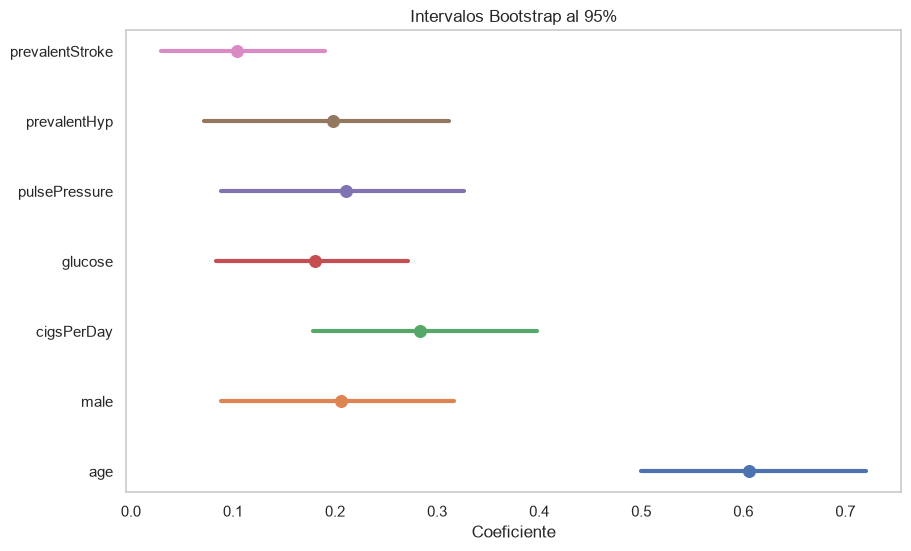

In [37]:
plt.figure(figsize=(10,6))

for i, variable in enumerate(variables_bootstrap):

    plt.plot(

        [ic_boot.loc[i,"IC inferior"],
         ic_boot.loc[i,"IC superior"]],

        [i,i],

        lw=3

    )

    plt.scatter(

        ic_boot.loc[i,"Coeficiente original"],

        i,

        s=70

    )

plt.yticks(

    range(len(variables_bootstrap)),

    variables_bootstrap

)

plt.xlabel(
    "Coeficiente"
)

plt.title(
    "Intervalos Bootstrap al 95%"
)

plt.grid()

plt.show()

### Interpretación

La validación mediante Bootstrap permitió evaluar la estabilidad de los coeficientes estimados por el modelo seleccionado.

Los intervalos de confianza obtenidos muestran que todos los coeficientes permanecen positivos y relativamente estables entre las distintas muestras Bootstrap. Ninguno de los intervalos incluye el valor cero, lo que sugiere que las variables conservan un efecto consistente sobre la predicción del riesgo de enfermedad coronaria.

La **edad** presentó el coeficiente de mayor magnitud y el intervalo de confianza más alejado del cero, confirmando que constituye el predictor más importante del modelo.

Variables como **glucosa**, **presión de pulso**, **hipertensión previa** y **consumo de cigarrillos por día** también mostraron intervalos relativamente estrechos, indicando una contribución estable al modelo predictivo.

En conjunto, estos resultados evidencian que el modelo seleccionado mantiene un comportamiento consistente frente al remuestreo, proporcionando evidencia de estabilidad y robustez en las estimaciones obtenidas.

# 5.1 Resumen de resultados

La siguiente tabla sintetiza las principales decisiones metodológicas y los resultados obtenidos durante el desarrollo del modelo predictivo.

In [38]:
resumen_final = pd.DataFrame({

    "Aspecto": [

        "Registros originales",

        "Registros utilizados",

        "Estrategia de imputación",

        "Modelo seleccionado",

        "Variables finales",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "AUC",

        "AIC",

        "BIC",

        "Bootstrap"

    ],

    "Resultado": [

        f"{len(df)}",

        f"{len(df_regresion)}",

        "Imputación mediante regresión",

        "Modelo 2 (Backward Elimination)",

        ", ".join(variables_modelo2),

        f"{modelo2['accuracy']:.4f}",

        f"{modelo2['precision']:.4f}",

        f"{modelo2['recall']:.4f}",

        f"{modelo2['f1']:.4f}",

        f"{modelo2['auc']:.4f}",

        f"{aic2:.2f}",

        f"{bic2:.2f}",

        "Coeficientes estables (IC Bootstrap no incluyen 0)"

    ]

})

resumen_final

,Aspecto,Resultado
0,Registros originales,4240
1,Registros utilizados,4240
2,Estrategia de imputación,Imputación mediante regresión
3,Modelo seleccionado,Modelo 2 (Backward Elimination)
4,Variables finales,"age, male, cigsPerDay, glucose, pulsePressure,..."
5,Accuracy,0.8514
6,Precision,0.6111
7,Recall,0.0570
8,F1-score,0.1043
9,AUC,0.7073


### Interpretación

La tabla resume los principales resultados obtenidos durante el desarrollo del modelo predictivo.

La estrategia de imputación mediante regresión permitió conservar la totalidad de los registros originales sin modificar de forma importante las distribuciones de las variables analizadas.

Entre los tres modelos evaluados, el **Modelo 2**, construido mediante selección hacia atrás (*Backward Elimination*), presentó el mejor equilibrio entre desempeño predictivo y complejidad, obteniendo los mejores valores de Accuracy, Precision, AUC y los menores criterios de información (AIC y BIC).

Finalmente, la validación mediante Bootstrap evidenció que los coeficientes del modelo permanecen estables frente al remuestreo, proporcionando evidencia adicional sobre la robustez del modelo seleccionado.

# 6. Conclusiones

## Conclusiones

En esta evaluación se desarrolló un proceso completo de modelamiento predictivo para estimar el riesgo de enfermedad coronaria a diez años utilizando el conjunto de datos del Framingham Heart Study.

En primer lugar, se compararon distintas estrategias para el tratamiento de datos faltantes. La imputación mediante regresión permitió conservar la totalidad de las observaciones sin alterar significativamente las distribuciones originales de las principales variables, constituyendo una alternativa más adecuada que la eliminación por casos completos.

Posteriormente se construyeron tres modelos de regresión logística utilizando diferentes estrategias de selección de variables. La comparación mediante Accuracy, Precision, Recall, F1-score, AUC y criterios de información permitió determinar que el **Modelo 2**, obtenido mediante selección hacia atrás (*Backward Elimination*), presentó el mejor equilibrio entre desempeño predictivo y complejidad, alcanzando el mayor AUC (0,7073) y los menores valores de AIC y BIC.

Finalmente, la validación mediante Bootstrap mostró que los coeficientes estimados permanecen estables frente al remuestreo, evidenciando la robustez del modelo seleccionado. La edad, la glucosa, la presión de pulso y el consumo de cigarrillos por día se consolidaron como algunos de los principales predictores del riesgo cardiovascular.

En conjunto, los resultados obtenidos permiten concluir que la combinación de una adecuada estrategia de imputación, selección de variables y validación mediante Bootstrap mejora la confiabilidad del modelo predictivo y proporciona una base sólida para futuras aplicaciones orientadas al apoyo de decisiones clínicas.